# 01 — Data Preprocessing

This notebook covers the full preprocessing pipeline for the IEEE-CIS Fraud Detection dataset. The goal is to get the data into a clean, model-ready state before training any models.

**Steps:**
1. Load and merge the raw files
2. Install and import libraries
3. Explore the data
4. Handle missing values
5. Encode categorical features
6. Train/validation/test split
7. Apply SMOTE to training set
8. Save processed files

In [2]:
# Install required libraries
%pip install pandas numpy scikit-learn xgboost imbalanced-learn shap lime tensorflow matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [3]:
# Load data
ieee_transactions = pd.read_csv("../data/raw/ieee_transaction.csv")
ieee_identity = pd.read_csv("../data/raw/ieee_identity.csv")

# Merge
ieee_data = ieee_transactions.merge(
    ieee_identity,
    on="TransactionID",
    how="left"
)

# Save processed
ieee_data.to_csv("../data/processed/ieee_full.csv", index=False)

In [4]:
df = pd.read_csv('../data/processed/ieee_full.csv')
print(df.shape)
df.head(3)

(590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Basic Exploration

In [5]:
# Class distribution
print(df['isFraud'].value_counts())
print(df['isFraud'].value_counts(normalize=True).round(4))

0    569877
1     20663
Name: isFraud, dtype: int64
0    0.965
1    0.035
Name: isFraud, dtype: float64


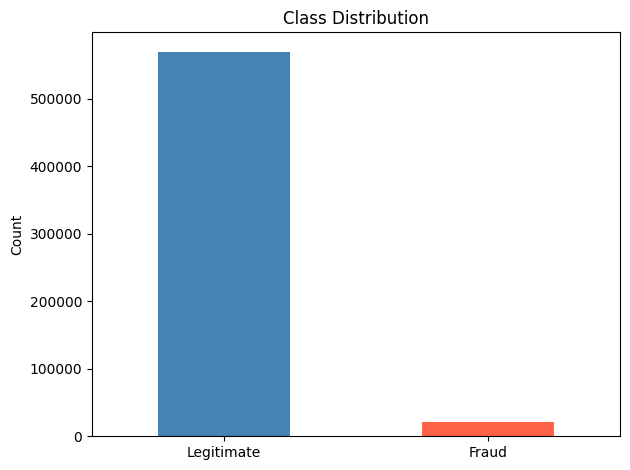

In [6]:
# Visualise class imbalance
df['isFraud'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Class Distribution')
plt.xticks([0, 1], ['Legitimate', 'Fraud'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../results/figures/class_distribution.png', dpi=150)
plt.show()

In [7]:
# Missing values summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(f'Columns with missing values: {len(missing_df)}')
missing_df.head(20)

Columns with missing values: 414


,missing_count,missing_pct
id_24,585793,99.20
id_07,585385,99.13
id_08,585385,99.13
id_21,585381,99.13
id_26,585377,99.13
id_25,585408,99.13
id_23,585371,99.12
id_27,585371,99.12
id_22,585371,99.12
dist2,552913,93.63


In [8]:
# Data types
print('Numeric columns:', df.select_dtypes(include='number').shape[1])
print('Categorical columns:', df.select_dtypes(include='object').shape[1])

Numeric columns: 403
Categorical columns: 31


## 3. Handle Missing Values

Columns with more than 90% missing values will be dropped — there is not enough information to impute them reliably. For the rest, numeric columns will be filled with the median and categorical columns with the mode.

In [9]:
# Drop columns with more than 90% missing
threshold = 0.9
cols_to_drop = missing_df[missing_df['missing_pct'] > threshold * 100].index.tolist()
df = df.drop(columns=cols_to_drop)
print(f'Dropped {len(cols_to_drop)} columns. Remaining: {df.shape[1]}')

Dropped 12 columns. Remaining: 422


In [10]:
# Fill remaining missing values
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Remove target from numeric cols
num_cols = [c for c in num_cols if c != 'isFraud']

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

print('Missing values remaining:', df.isnull().sum().sum())

Missing values remaining: 0


## 4. Encode Categorical Features

Label encoding is used here since tree-based models (Random Forest, XGBoost) can handle ordinal-style encodings well.

In [11]:
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print('All categorical columns encoded.')
print(df.shape)

All categorical columns encoded.
(590540, 422)


## 5. Train / Validation / Test Split

Splitting 70/15/15 with stratification to preserve the fraud ratio in each set. The test set will not be touched until final evaluation.

In [12]:
X = df.drop(columns=['isFraud'])
y = df['isFraud']

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Second split: 15% val, 15% test from the 30% temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f'Train:      {X_train.shape[0]} rows | Fraud rate: {y_train.mean():.4f}')
print(f'Validation: {X_val.shape[0]} rows  | Fraud rate: {y_val.mean():.4f}')
print(f'Test:       {X_test.shape[0]} rows  | Fraud rate: {y_test.mean():.4f}')

Train:      413378 rows | Fraud rate: 0.0350
Validation: 88581 rows  | Fraud rate: 0.0350
Test:       88581 rows  | Fraud rate: 0.0350


## 6. Apply SMOTE

SMOTE is applied only to the training set to address class imbalance. Applying it to validation or test sets would cause data leakage and give a false picture of model performance.

In [13]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'Before SMOTE: {y_train.value_counts().to_dict()}')
print(f'After SMOTE:  {pd.Series(y_train_sm).value_counts().to_dict()}')

Before SMOTE: {0: 398914, 1: 14464}
After SMOTE:  {0: 398914, 1: 398914}


## 7. Descriptive Statistics

In [14]:
# Transaction amount by class
df.groupby('isFraud')['TransactionAmt'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.51,239.40,0.25,43.97,68.5,120.0,31937.39
1,20663.0,149.24,232.21,0.29,35.04,75.0,161.0,5191.00


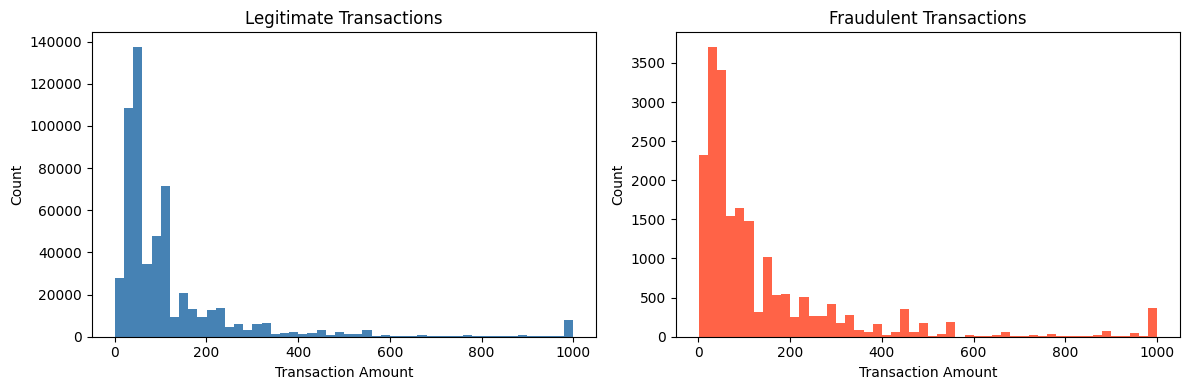

In [15]:
# Transaction amount distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['isFraud'] == 0]['TransactionAmt'].clip(upper=1000).plot(
    kind='hist', bins=50, ax=axes[0], color='steelblue', title='Legitimate Transactions'
)
df[df['isFraud'] == 1]['TransactionAmt'].clip(upper=1000).plot(
    kind='hist', bins=50, ax=axes[1], color='tomato', title='Fraudulent Transactions'
)

for ax in axes:
    ax.set_xlabel('Transaction Amount')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('../results/figures/transaction_amt_distribution.png', dpi=150)
plt.show()

## 8. Save Processed Files

In [16]:
import os
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../results/figures', exist_ok=True)

# Save splits
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_val.to_csv('../data/processed/X_val.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)

y_train.to_csv('../data/processed/y_train.csv', index=False)
y_val.to_csv('../data/processed/y_val.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

# Save SMOTE-resampled training set
pd.DataFrame(X_train_sm, columns=X.columns).to_csv('../data/processed/X_train_smote.csv', index=False)
pd.Series(y_train_sm, name='isFraud').to_csv('../data/processed/y_train_smote.csv', index=False)

print('All files saved.')

All files saved.


## Summary

| Step | Detail |
|------|--------|
| Raw shape | 590,540 rows × 434 columns |
| Columns dropped (>90% missing) | 12 columns |
| Imputation | Median (numeric), Mode (categorical) |
| Encoding | Label Encoding |
| Train size | ~413,378 rows |
| Validation size | ~88,581 rows |
| Test size | ~88,581 rows |
| SMOTE applied | Training set only |